In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import requests
import os
from datetime import datetime, timedelta

In [4]:
# данные месячные
data_month = pd.read_csv("../data/analytics/monthly_turnovers_2022-01-01_2026-05-31.csv", encoding="utf-8-sig")
# дату красивее
data_month["date"] = pd.to_datetime(data_month[["year", "month"]].assign(day=1))
data_month["date"] = data_month["date"].dt.strftime("%m.%y")
# убрать выброс в начале 2022 год
mask = ~((data_month["year"] == 2022) & (data_month["month"] <= 3))
data_month_filtered = data_month[mask]

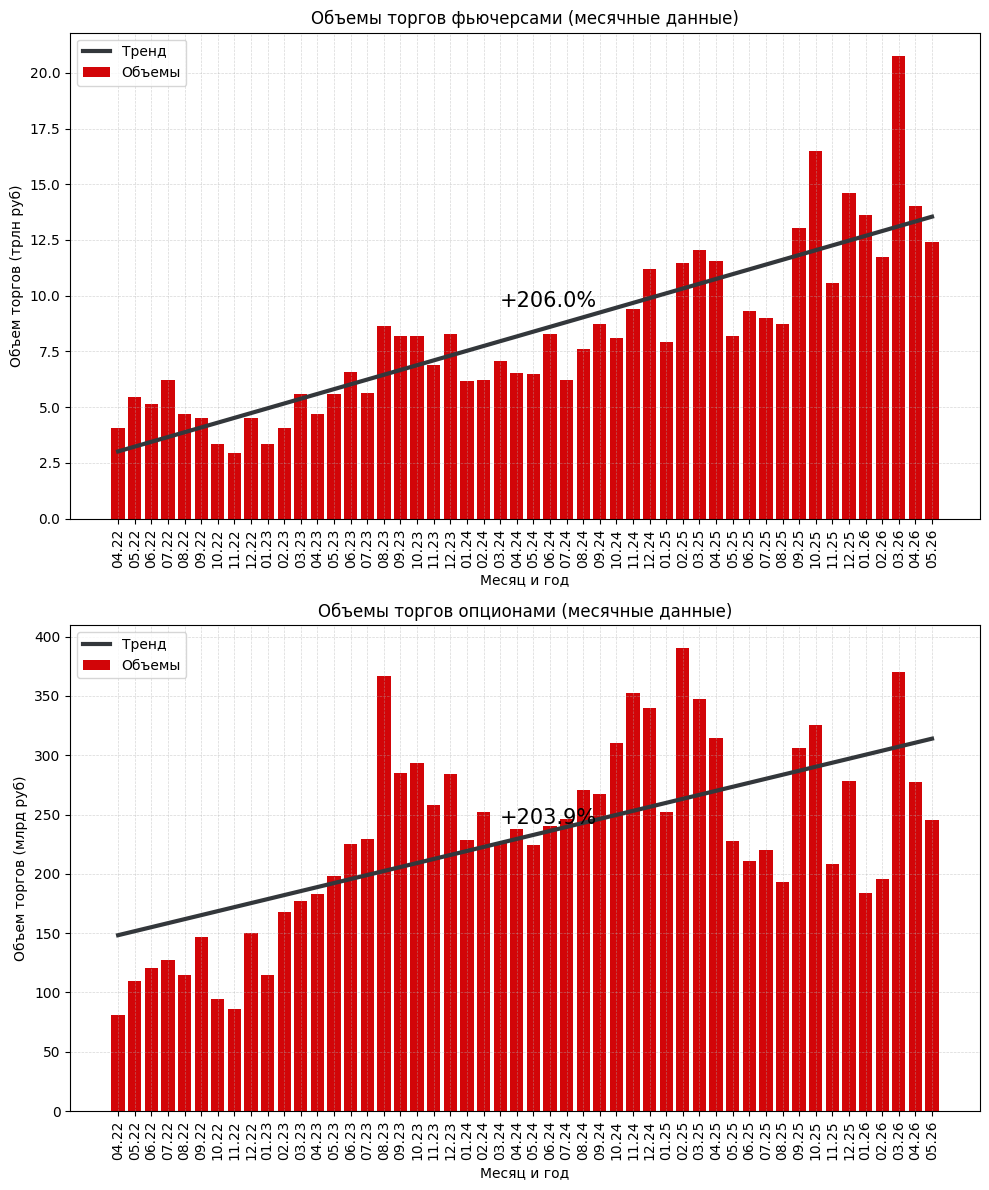

In [5]:
# фьючерсы, месяцы
df_futures_month = data_month_filtered[data_month_filtered["instrument_type"] == "futures"].copy()
# опционы, месяцы
df_options_month = data_month_filtered[data_month_filtered["instrument_type"] == "options"].copy()

# график фьючерсов
fig, axes = plt.subplots(nrows = 2, ncols = 1, figsize=(10, 12))
axes[0].set_title("Объемы торгов фьючерсами (месячные данные)")
axes[0].set_xlabel("Месяц и год")
axes[0].set_ylabel("Объем торгов (трлн руб)")
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(True, linestyle = '--', linewidth = 0.5)
axes[0].bar(df_futures_month["date"], df_futures_month["value_rub_mm"] / 1000000, color = (210/255, 5/255, 8/255), label='Объемы')
# добавляем тренд
x = np.arange(len(df_futures_month))
y = df_futures_month["value_rub_mm"] / 1000000
z = np.polyfit(x, y, 1)
mid = df_futures_month["value_rub_mm"].iloc[len(df_futures_month["value_rub_mm"]) // 2] / 1000000
p = np.poly1d(z)
axes[0].plot(x, p(x), color=(51/255, 55/255, 59/255), linewidth=3, label='Тренд')
axes[0].legend(loc='upper left')
first_value = df_futures_month["value_rub_mm"].iloc[0] / 1000000
last_value = df_futures_month["value_rub_mm"].iloc[-1] / 1000000
growth_percent = ((last_value - first_value) / first_value) * 100
growth_text = f'+{growth_percent:.1f}%'
axes[0].text(23, mid + 3, growth_text,fontsize=15)

# график опционов
axes[1].set_title("Объемы торгов опционами (месячные данные)")
axes[1].set_xlabel("Месяц и год")
axes[1].set_ylabel("Объем торгов (млрд руб)")
axes[1].tick_params(axis='x', rotation=90)
axes[1].bar(df_options_month["date"], df_options_month["value_rub_mm"] / 1000, color = (210/255, 5/255, 8/255), label='Объемы')
axes[1].grid(True, linestyle = '--', linewidth = 0.5)
# добавляем тренд
x1 = np.arange(len(df_options_month))
y1 = df_options_month["value_rub_mm"] / 1000
z1 = np.polyfit(x1, y1, 1)
p1 = np.poly1d(z1)
axes[1].plot(x1, p1(x1), color=(51/255, 55/255, 59/255), linewidth=3, label='Тренд')
axes[1].legend(loc='upper left')
first_value = df_options_month["value_rub_mm"].iloc[0] / 1000
last_value = df_options_month["value_rub_mm"].iloc[-1] / 1000
mid1 = df_options_month["value_rub_mm"].iloc[len(df_options_month["value_rub_mm"]) // 2] / 1000
growth_percent1 = ((last_value - first_value) / first_value) * 100
growth_text1 = f'+{growth_percent1:.1f}%'
axes[1].text(23, mid1 + 18, growth_text1, fontsize=15)

plt.tight_layout()
plt.show()

In [6]:
# данные квартальные
data_quarter = pd.read_csv("../data/analytics/quarterly_turnovers_2022-01-01_2026-05-31.csv", encoding="utf-8-sig")
# дату красивее
data_quarter["date"] = "Q" + data_quarter["quarter"].astype(str) + "." + data_quarter["year"].astype(str).str[-2:]
# убрать выброс в начале 2022 года
mask = ~((data_quarter["year"] == 2022) & (data_quarter["quarter"] <= 1))
data_quarter_filtered = data_quarter[mask]

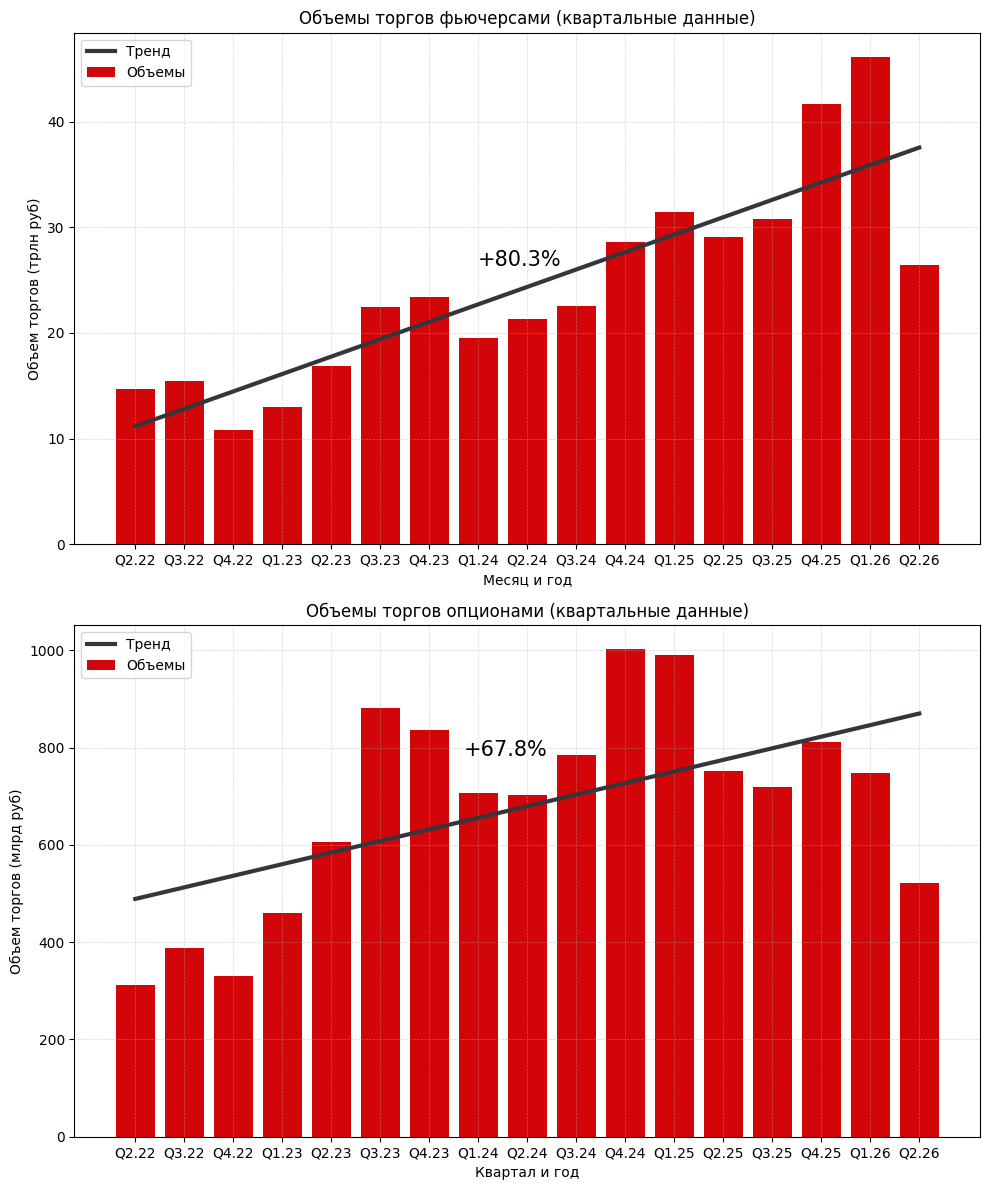

In [7]:
# фьючерсы, кварталы
df_futures_quarter = data_quarter_filtered[data_quarter_filtered["instrument_type"] == "futures"].copy()
# опционы, кваquarter
df_options_quarter = data_quarter_filtered[data_quarter_filtered["instrument_type"] == "options"].copy()

# график фьючерсов
fig, axes = plt.subplots(nrows = 2, ncols = 1, figsize=(10, 12))
axes[0].set_title("Объемы торгов фьючерсами (квартальные данные)")
axes[0].set_xlabel("Месяц и год")
axes[0].set_ylabel("Объем торгов (трлн руб)")
# axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(True, linestyle = '--', linewidth = 0.5)
axes[0].bar(df_futures_quarter["date"], df_futures_quarter["value_rub_mm"] / 1000000, color = (210/255, 5/255, 8/255), label='Объемы')
# добавляем тренд
x = np.arange(len(df_futures_quarter))
y = df_futures_quarter["value_rub_mm"] / 1000000
z = np.polyfit(x, y, 1)
mid = df_futures_quarter["value_rub_mm"].iloc[len(df_futures_quarter["value_rub_mm"]) // 2] / 1000000
p = np.poly1d(z)
axes[0].plot(x, p(x), color=(51/255, 55/255, 59/255), linewidth=3, label='Тренд')
axes[0].legend(loc='upper left')
first_value = df_futures_quarter["value_rub_mm"].iloc[0] / 1000000
last_value = df_futures_quarter["value_rub_mm"].iloc[-1] / 1000000
growth_percent = ((last_value - first_value) / first_value) * 100
growth_text = f'+{growth_percent:.1f}%'
axes[0].text(7, mid + 5, growth_text,fontsize=15)

# график опционов
axes[1].set_title("Объемы торгов опционами (квартальные данные)")
axes[1].set_xlabel("Квартал и год")
axes[1].set_ylabel("Объем торгов (млрд руб)")
# axes[1].tick_params(axis='x', rotation=90)
axes[1].bar(df_options_quarter["date"], df_options_quarter["value_rub_mm"] / 1000, color = (210/255, 5/255, 8/255), label='Объемы')
axes[1].grid(True, linestyle = '--', linewidth = 0.5)
# добавляем тренд
x1 = np.arange(len(df_options_quarter))
y1 = df_options_quarter["value_rub_mm"] / 1000
z1 = np.polyfit(x1, y1, 1)
p1 = np.poly1d(z1)
axes[1].plot(x1, p1(x1), color=(51/255, 55/255, 59/255), linewidth=3, label='Тренд')
axes[1].legend(loc='upper left')
first_value = df_options_quarter["value_rub_mm"].iloc[0] / 1000
last_value = df_options_quarter["value_rub_mm"].iloc[-1] / 1000
mid1 = df_options_quarter["value_rub_mm"].iloc[len(df_options_quarter["value_rub_mm"]) // 2] / 1000
growth_percent1 = ((last_value - first_value) / first_value) * 100
growth_text1 = f'+{growth_percent1:.1f}%'
axes[1].text(6.7, mid1 + 80, growth_text1, fontsize=15)

plt.tight_layout()
plt.show()

In [8]:
# данные годовые
data_year = pd.read_csv("../data/analytics/yearly_turnovers_2022-01-01_2026-05-31.csv", encoding="utf-8-sig")
# дату красивее
data_year["date"] = data_year["year"].astype(str)
# убрать выброс в начале 2022 года
mask = ~((data_year["year"] == 2022) | (data_year["year"] == 2026))
data_year_filtered = data_year[mask]

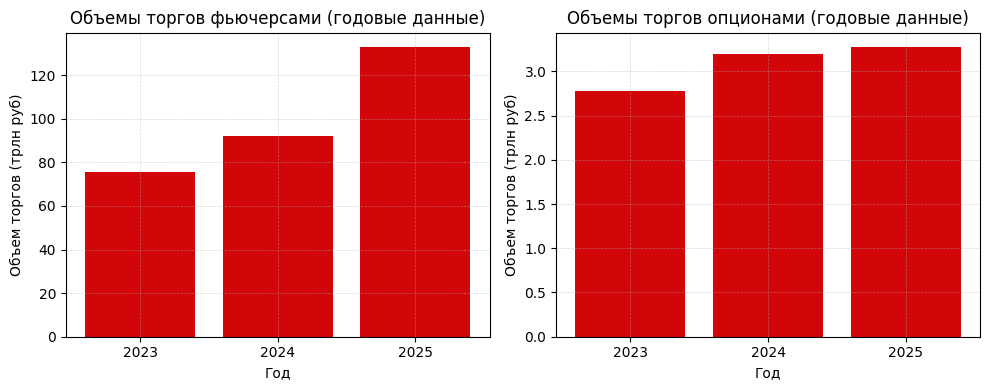

In [20]:
# фьючерсы, годы
df_futures_year = data_year_filtered[data_year_filtered["instrument_type"] == "futures"].copy()
# опционы, годы
df_options_year = data_year_filtered[data_year_filtered["instrument_type"] == "options"].copy()

# график фьючерсов
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize=(10, 4))
axes[0].set_title("Объемы торгов фьючерсами (годовые данные)")
axes[0].set_xlabel("Год")
axes[0].set_ylabel("Объем торгов (трлн руб)")
# axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(True, linestyle = '--', linewidth = 0.5)
axes[0].bar(df_futures_year["date"], df_futures_year["value_rub_mm"] / 1000000, color = (210/255, 5/255, 8/255), label='Объемы')

# график опционов
axes[1].set_title("Объемы торгов опционами (годовые данные)")
axes[1].set_xlabel("Год")
axes[1].set_ylabel("Объем торгов (трлн руб)")
# axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(True, linestyle = '--', linewidth = 0.5)
axes[1].bar(df_options_year["date"], df_options_year["value_rub_mm"] / 1000000, color = (210/255, 5/255, 8/255), label='Объемы')

plt.tight_layout()
plt.show()

In [64]:
# все что есть по комиссиям
url = "https://iss.moex.com/iss/statistics/engines/futures/promo.json"
params = {
    "date": "2022-05-27", # дата, к сожалению, ни на что не влияет
}
request = requests.get(url, params=params)
data = request.json()
df = pd.DataFrame(
    data['futures_promo']['data'],
    columns=data['futures_promo']['columns']
)
date = df['updated_at'][0]
fee_forts = df['fee_forts'][0]
fee_options = df['fee_options'][0]
print(f'значит комиссия {date} суммарная по фьючам была {fee_forts} рублей')
print(f'значит комиссия {date} суммарная по фьючам была {fee_options} рублей')
df

значит комиссия 2025-06-02 18:50:00 суммарная по фьючам была 16364470 рублей
значит комиссия 2025-06-02 18:50:00 суммарная по фьючам была 198456 рублей


,fee_forts,fee_options,fee_all,updated_at
0,16364470,198456,16562926,2025-06-02 18:50:00


In [37]:
# посмотрим на данные за 2025-06-02
df_futures = pd.read_csv("../data/daily/futures_turnovers_2022-01-01_2026-05-31.csv", encoding="utf-8-sig")
df_options = pd.read_csv("../data/daily/options_turnovers_2022-01-01_2026-05-31.csv", encoding="utf-8-sig")
value_forts = df_futures[df_futures["date"] == "2025-06-02"]["value_rub_mm"].values[0]
value_options = df_options[df_options["date"] == "2025-06-02"]["value_rub_mm"].values[0]
num_trades_forts = df_futures[df_futures["date"] == "2025-06-02"]["num_trades"].values[0]
num_trades_options = df_options[df_options["date"] == "2025-06-02"]["num_trades"].values[0]
fee_per_1m_forts = fee_forts / value_forts
fee_per_1m_options = fee_options / value_options
fee_per_trade_forts = fee_forts / num_trades_forts
fee_per_trade_options = fee_options / num_trades_options
print(f'До коррекции: примерная комиссия по фьючерсам: {fee_per_1m_forts} руб за млн руб оборота')
print(f'До коррекции: примерная комиссия по опционам: {fee_per_1m_options} руб за млн руб оборота')
print(f'До коррекции: примерная комиссия по фьючерсам: {fee_per_trade_forts} руб за сделку')
print(f'До коррекции: примерная комиссия по опционам: {fee_per_trade_options} руб за сделку')

До коррекции: примерная комиссия по фьючерсам: 34.99198128499643 руб за млн руб оборота
До коррекции: примерная комиссия по опционам: 15.322643263935563 руб за млн руб оборота
До коррекции: примерная комиссия по фьючерсам: 10.12914850499696 руб за сделку
До коррекции: примерная комиссия по опционам: 11.043125034778253 руб за сделку


In [38]:
# посчитаем комиссию за 2023, 2024 и 2025 годы через эти прокси ставок комиссии и скорректируем исходя из фактических комиссионных на срочном рынке
real_commission_2023 = 6703.7 * 1_000_000
real_commission_2024 = 8946.4 * 1_000_000
real_commission_2025 = 12945.2 * 1_000_000

est_commission_1m_forts_2023 = (df_futures_year[df_futures_year['year'] == 2023]['value_rub_mm'].iloc[0] * fee_per_1m_forts)
est_commission_1m_forts_2024 = (df_futures_year[df_futures_year['year'] == 2024]['value_rub_mm'].iloc[0] * fee_per_1m_forts)
est_commission_1m_forts_2025 = (df_futures_year[df_futures_year['year'] == 2025]['value_rub_mm'].iloc[0] * fee_per_1m_forts)
est_commission_1m_options_2023 = (df_options_year[df_options_year['year'] == 2023]['value_rub_mm'].iloc[0] * fee_per_1m_options)
est_commission_1m_options_2024 = (df_options_year[df_options_year['year'] == 2024]['value_rub_mm'].iloc[0] * fee_per_1m_options)
est_commission_1m_options_2025 = (df_options_year[df_options_year['year'] == 2025]['value_rub_mm'].iloc[0] * fee_per_1m_options)

est_commission_pt_forts_2023 = (df_futures_year[df_futures_year['year'] == 2023]['num_trades'].iloc[0] * fee_per_trade_forts)
est_commission_pt_forts_2024 = (df_futures_year[df_futures_year['year'] == 2024]['num_trades'].iloc[0] * fee_per_trade_forts)
est_commission_pt_forts_2025 = (df_futures_year[df_futures_year['year'] == 2025]['num_trades'].iloc[0] * fee_per_trade_forts)
est_commission_pt_options_2023 = (df_options_year[df_options_year['year'] == 2023]['num_trades'].iloc[0] * fee_per_trade_options)
est_commission_pt_options_2024 = (df_options_year[df_options_year['year'] == 2024]['num_trades'].iloc[0] * fee_per_trade_options)
est_commission_pt_options_2025 = (df_options_year[df_options_year['year'] == 2025]['num_trades'].iloc[0] * fee_per_trade_options)

corr_by_value = (
    (real_commission_2023 / (est_commission_1m_forts_2023 + est_commission_1m_options_2023)) +
    (real_commission_2024 / (est_commission_1m_forts_2024 + est_commission_1m_options_2024)) +
    (real_commission_2025 / (est_commission_1m_forts_2025 + est_commission_1m_options_2025))
) / 3

corr_by_num_trades = (
    (real_commission_2023 / (est_commission_pt_forts_2023 + est_commission_pt_options_2023)) +
    (real_commission_2024 / (est_commission_pt_forts_2024 + est_commission_pt_options_2024)) +
    (real_commission_2025 / (est_commission_pt_forts_2025 + est_commission_pt_options_2025))
) / 3

# итого корректирующие коэффициенты дают нам более близкие прокси комиссионных ставок
print(corr_by_value)
print(corr_by_num_trades)
fee_per_1m_forts_corr = corr_by_value * fee_per_1m_forts
fee_per_1m_options_corr = corr_by_value * fee_per_1m_options
fee_per_trade_forts_corr = corr_by_num_trades * fee_per_trade_forts
fee_per_trade_options_corr = corr_by_num_trades * fee_per_trade_options
# скорректированные комиссии:
print(fee_per_1m_forts_corr)
print(fee_per_1m_options_corr)
print(fee_per_trade_forts_corr)
print(fee_per_trade_options_corr)

2.6609983201317764
2.8086747065144806
93.11360341745805
40.77352798531101
28.44948320451393
31.016545966058523


In [39]:
# теперь посмотрим, какие примерные объемы комиссий были с 03.2022 по 05.2026 способом с подсчетом по value

df_futures_month['commission_value_type'] = (df_futures_month['value_rub_mm'] * fee_per_1m_forts_corr)

df_futures_quarter['commission_value_type'] = (df_futures_quarter['value_rub_mm'] * fee_per_1m_forts_corr)

df_futures_year['commission_value_type'] = (df_futures_year['value_rub_mm'] * fee_per_1m_forts_corr)

df_options_month['commission_value_type'] = (df_options_month['value_rub_mm'] * fee_per_1m_options_corr)

df_options_quarter['commission_value_type'] = (df_options_quarter['value_rub_mm'] * fee_per_1m_options_corr)

df_options_year['commission_value_type'] = (df_options_year['value_rub_mm'] * fee_per_1m_options_corr)

# теперь посмотрим, какие примерные объемы комиссий были с 03.2022 по 05.2026 способом с подсчетом по num_trades

df_futures_month['commission_trade_type'] = (df_futures_month['num_trades'] * fee_per_trade_forts_corr)

df_futures_quarter['commission_trade_type'] = (df_futures_quarter['num_trades'] * fee_per_trade_forts_corr)

df_futures_year['commission_trade_type'] = (df_futures_year['num_trades'] * fee_per_trade_forts_corr)

df_options_month['commission_trade_type'] = (df_options_month['num_trades'] * fee_per_trade_options_corr)

df_options_quarter['commission_trade_type'] = (df_options_quarter['num_trades'] * fee_per_trade_options_corr)

df_options_year['commission_trade_type'] = (df_options_year['num_trades'] * fee_per_trade_options_corr)

In [62]:
# сохраняем информацию в json для дальнейшего использования
commission_params = {
    "description": {
    "fee_per_1m_forts": "Model fee in RUB for futures per 1 million RUB trading volume before adjustment",
    "fee_per_1m_options": "Model fee in RUB for options per 1 million RUB trading volume before adjustment",
    "fee_per_trade_forts": "Model fee in RUB for futures per trade before adjustment",
    "fee_per_trade_options": "Model fee in RUB for options per trade before adjustment",
    "corr_by_value": "Adjustment factor for fees based on trading value (ratio)",
    "corr_by_num_trades": "Adjustment factor for fees based on number of trades (ratio)",
    "fee_per_1m_forts_corr": "Model fee in RUB for futures per 1 million RUB trading volume after adjustment",
    "fee_per_1m_options_corr": "Model fee in RUB for options per 1 million RUB trading volume after adjustment",
    "fee_per_trade_forts_corr": "Model fee in RUB for futures per trade after adjustment",
    "fee_per_trade_options_corr": "Model fee in RUB for options per trade after adjustment"
    },
    "data": {
    "fee_per_1m_forts": fee_per_1m_forts,
    "fee_per_1m_options": fee_per_1m_options,
    "fee_per_trade_forts": fee_per_trade_forts,
    "fee_per_trade_options": fee_per_trade_options,
    "corr_by_value": corr_by_value,
    "corr_by_num_trades": corr_by_num_trades,
    "fee_per_1m_forts_corr": fee_per_1m_forts_corr,
    "fee_per_1m_options_corr": fee_per_1m_options_corr,
    "fee_per_trade_forts_corr": fee_per_trade_forts_corr,
    "fee_per_trade_options_corr": fee_per_trade_options_corr,
    },
}

In [63]:
os.makedirs("../data/model_params", exist_ok=True)
file_name = "commission_params.json"
with open(f"../data/model_params/{file_name}", "w") as file:
    json.dump(commission_params, file, indent=4) # indent=4 для отступов
